In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Import Logistic regression classifier
from sklearn.linear_model import LogisticRegression
#Import accuracy metric to evaluate model performance
from sklearn.metrics import accuracy_score
#import Linear Discriminant Analysis for supervised dimensionality reduction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
#Import built-in forest CoverType dataset
from sklearn.datasets import fetch_covtype

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=fetch_covtype()
#Randomly select 5000 samples to reduce runtime
subset_indices=np.random.choice(range(len(data.data)), 5000, replace=False)
#Extract feature matrix using selected indices
X=data.data[subset_indices]
#Extract corresponding target labels
Y=data.target[subset_indices]

print("Dataset Shape:", X.shape)
print("Target Shape:", Y.shape)

Dataset Shape: (5000, 54)
Target Shape: (5000,)


In [ ]:
scaler=StandardScaler()
#Fit scaler on features and transform them to zero mean and unit variance
X_scaled=scaler.fit_transform(X)

In [ ]:
#Split scaled data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [ ]:
#Create logistic Regression model with higher iterations for convergence
model_before_lda= LogisticRegression(max_iter=500, random_state=42, multi_class='ovr')
#Train model using training data
model_before_lda.fit(X_train, Y_train)
#Predict labels for test data
Y_pred_before_lda=model_before_lda.predict(X_test)
#Compute accuracy score
accuracy_before_lda=accuracy_score(Y_test, Y_pred_before_lda)
#Print accuracy before applying LDA
print("Accuracy before LDA:", round(accuracy_before_lda, 3))

Accuracy before LDA: 0.699


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
lda=LDA(n_components=6)

X_lda=lda.fit_transform(X_scaled, Y)

In [ ]:
expVar=lda.explained_variance_ratio_

explained_variance_df=pd.DataFrame({
    "LDA Component": [f"LD{i+1}" for i in range(len(expVar))],
    "Explained Variance": expVar
})
explained_variance_df

,LDA Component,Explained Variance
0,LD1,0.671759
1,LD2,0.211447
2,LD3,0.061083
3,LD4,0.028279
4,LD5,0.014564
5,LD6,0.012868


In [ ]:
X_train_lda, X_test_lda, Y_train_lda, Y_test_lda = train_test_split(X_lda, Y, test_size=0.2, random_state=42)

In [ ]:
model_after_lda= LogisticRegression(max_iter=500, random_state=42, multi_class='ovr')

model_after_lda.fit(X_train_lda, Y_train_lda)

Y_pred_after_lda=model_after_lda.predict(X_test_lda)

accuracy_after_lda=accuracy_score(Y_test_lda, Y_pred_after_lda)

print("Accuracy after LDA:", round(accuracy_after_lda, 3))

Accuracy after LDA: 0.685


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
comparision_df=pd.DataFrame({
    "Model": ["Logistic Regression (Before LDA)", "Logistic Regression (After LDA)"],
    "Accuracy": [round(accuracy_before_lda, 3), round(accuracy_after_lda, 3)]
})

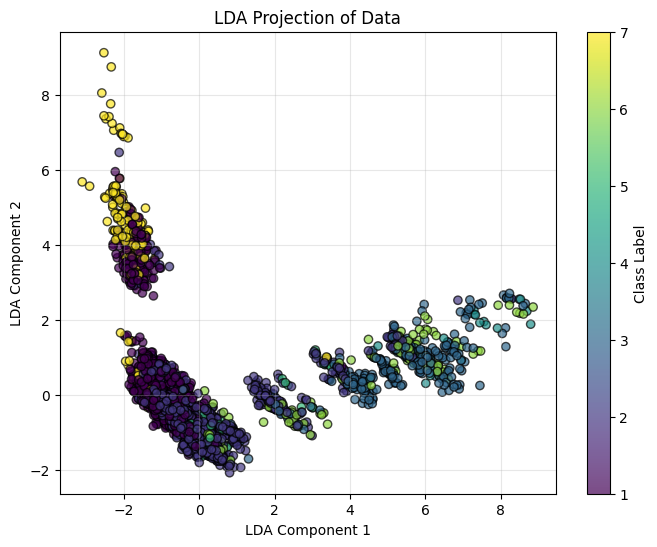

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    c=Y,
    cmap='viridis',
    edgecolors='k',
    alpha=0.7
)

plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA Projection of Data")
plt.colorbar(label="Class Label")
plt.grid(alpha=0.3)
plt.show()

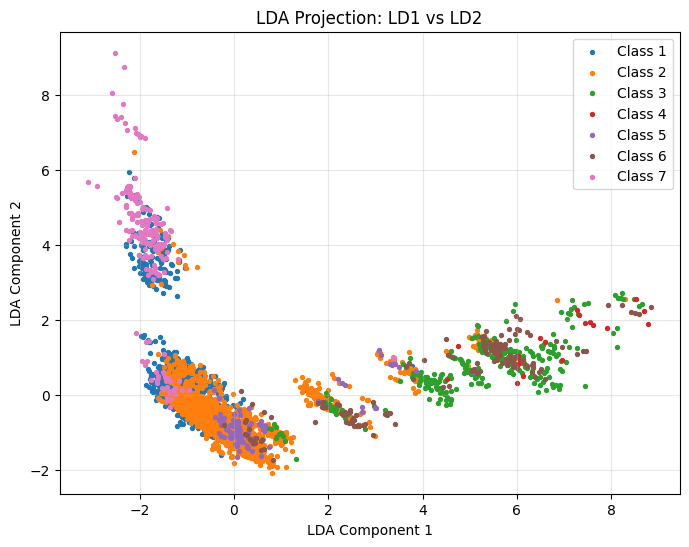

In [ ]:
classes=np.unique(Y)

def plot_lda_pair(X_lda, Y, component1, component2):
    plt.figure(figsize=(8, 6))

    for cls in classes:
      plt.scatter(
          X_lda[Y==cls, component1],
          X_lda[Y==cls, component2],
          s=8,
          label=f"Class {cls}"
      )
    plt.xlabel(f"LDA Component {component1+1}")
    plt.ylabel(f"LDA Component {component2+1}")
    plt.title(f"LDA Projection: LD{component1+1} vs LD{component2+1}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_lda_pair(X_lda, Y, 0, 1)